Peligros Hidrometeorológicos 2025-1 <p>
**Taller en Python - Indices climáticos**<p>
Pedro Rau, PhD - praul@uni.edu.pe

#1. Leyendo datos de Temperatura Superficial del Mar desde un archivo MS-Excel
---





Leer el archivo MS Excel "datos.xlsx" y la hoja "indice" que contienen el indice mensual SST3.4 de la NOAA enel periodo 1990-2020. Plotear la serie. NOTA: En el Colab, icono "Archivos" de la izquierda, subir el archivo "datos.xlsx" y copiar la ruta.

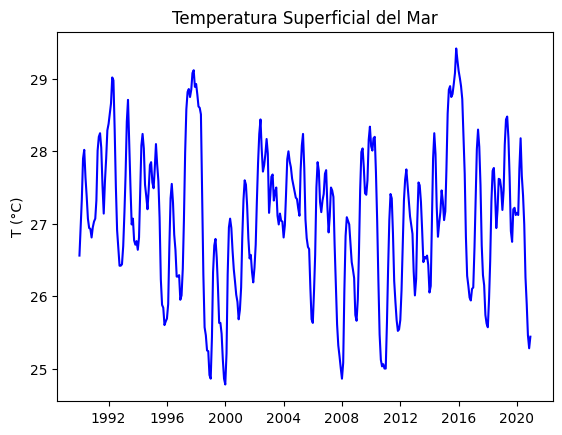

[26.56 26.96 27.33 27.9  28.02 27.64 27.38 27.07 26.94 26.93 26.81 26.95
 27.03 27.07 27.32 28.01 28.2  28.25 28.05 27.53 27.14 27.58 27.9  28.29
 28.38 28.53 28.66 29.02 28.98 28.3  27.51 26.91 26.65 26.42 26.42 26.44
 26.69 27.16 27.67 28.41 28.71 28.08 27.52 26.99 27.07 26.77 26.71 26.76
 26.64 26.81 27.39 28.08 28.24 28.04 27.54 27.38 27.2  27.47 27.81 27.85
 27.57 27.49 27.75 28.1  27.82 27.59 27.08 26.23 25.88 25.84 25.6  25.65
 25.69 25.89 26.67 27.35 27.55 27.29 26.85 26.64 26.27 26.27 26.29 25.95
 26.01 26.38 27.04 27.98 28.58 28.82 28.86 28.75 28.85 29.08 29.12 28.89
 28.93 28.78 28.62 28.6  28.51 27.34 26.3  25.57 25.46 25.25 25.24 24.91
 24.86 25.43 26.33 26.7  26.79 26.53 26.13 25.63 25.63 25.48 25.12 24.86
 24.78 25.21 26.3  26.95 27.07 26.94 26.63 26.37 26.2  26.02 25.92 25.68
 25.81 26.12 26.8  27.33 27.6  27.54 27.25 26.8  26.52 26.57 26.33 26.19
 26.39 26.71 27.29 27.84 28.24 28.44 28.03 27.72 27.81 27.96 28.17 27.97
 27.15 27.39 27.65 27.68 27.32 27.44 27.5  27.11 26

In [ ]:
# Lectura de variable climatica
archivo = "/content/datos.xlsx" # Ingresar la ruta del archivo xlsx
hoja = "indice" # Ingresar la hoja a emplear

### NO EDITAR
# Llamando librerias
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
# Definicion de las cabeceras de meses del archivo xlsx
c = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
# Lectura del archivo xlsx y la hoja "indice" - cambiar el nombre de la hoja deseada y la 'ruta' grabada previamente
data = pd.read_excel(archivo,usecols=c,sheet_name=hoja)
fecha = pd.read_excel(archivo,usecols=["Año"])
start = str(fecha.iat[0,0])
end = str(fecha.iat[0,0]+len(fecha.index))
x = np.arange(np.datetime64(start), np.datetime64(end),np.timedelta64(1, 'M'),  dtype='datetime64[M]')
# Transformacion dataframe a vector y plot mensual
p1 = data.to_numpy()
q1 = np.reshape(p1, -1)
plt.plot(x,q1, color = 'b')
plt.ylabel("T (°C)")
plt.title('Temperatura Superficial del Mar')
plt.show()
print(q1)

#2. Generando indices mensuales predictores
---





De la serie anterior, convertir las temperaturas a valores de indices estandarizados mensuales para el mismo periodo de analisis (1990-2020).

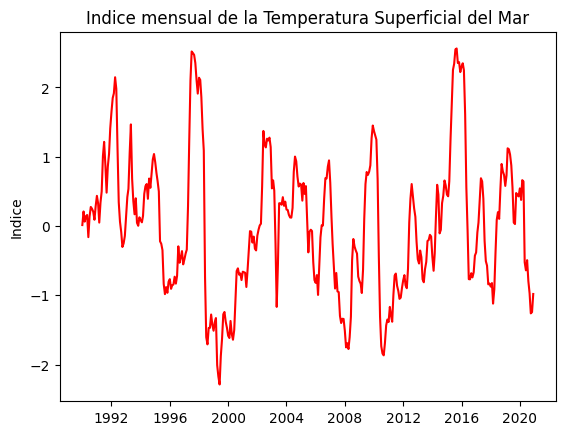

[ 0.01360714  0.20976964  0.06334063  0.14102124  0.15897506 -0.160732
  0.13513444  0.27519534  0.24907446  0.20645451  0.09053878  0.28483978
  0.43542852  0.32458737  0.04941468  0.3381042   0.50015999  1.00828422
  1.21465073  0.88361171  0.48164399  0.85544958  1.04063363  1.40850971
  1.64704313  1.84853179  1.91549255  2.14768412  1.97862802  1.10410522
  0.34459283  0.06357226 -0.08815135 -0.30275701 -0.24940341 -0.14282564
  0.13028114  0.41852915  0.53682308  1.05476952  1.46685062  0.68249281
  0.36070501  0.1693838   0.40024465  0.04670188  0.00337412  0.12551344
  0.08540653  0.0532      0.14689636  0.46352063  0.57597886  0.60583601
  0.39292938  0.68521507  0.55141485  0.74561965  0.96218543  1.03954347
  0.92007437  0.76298234  0.64823071  0.4993539  -0.22011931 -0.256553
 -0.34823106 -0.83582585 -0.98354403 -0.8818603  -0.96415366 -0.80528777
 -0.76721116 -0.90709374 -0.85577235 -0.84439357 -0.73189671 -0.83147901
 -0.71881128 -0.2935417  -0.53003345 -0.4525251  -0.362

In [ ]:
# Conversion a indice mensual y plot
idx = data.apply(stats.zscore)
p2 = idx.to_numpy()
q2 = np.reshape(p2, -1)
plt.plot(x,q2, color = 'r')
plt.ylabel("Indice")
plt.title('Indice mensual de la Temperatura Superficial del Mar')
plt.show()
print(q2)

#3. Generando indices estacionales anuales predictores
---





Estimar los indices estacionales anuales para el periodo Diciembre-Enero-Febrero (DEF) para la Temperatura Superficial del Mar. Los cuales servirán de predictores para una predicción estacional trimestral.




Indice estacional:
0.34828522348816726
1.6346948798371128
0.1353282145659991
0.08803999156883145
0.9075333911400425
-0.8265308917586166
-0.47645548078845673
2.053930195356129
-1.441730767992306
-1.5561850440207872
-0.7022211241930996
-0.18087061948952132
0.7806336030008034
0.273516785416553
0.5250648172718352
-0.7699879631101254
0.5658232151464516
-1.5355551604621127
-0.7859937490350873
1.3750050938706924
-1.3016251756803545
-0.7971541828543924
-0.41615327828067405
-0.4138231763269496
0.48968891553851485
2.2912265696556386
-0.3007190171126883
-0.8429815791009431
0.6827858987829959
0.4490999218191461


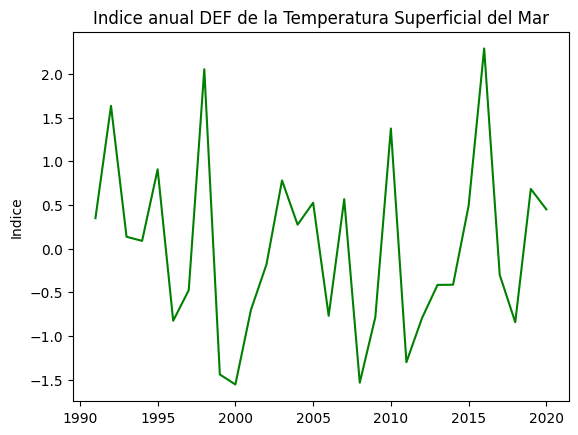

In [ ]:
# Calculo de un indice estacional
start = 12  # ingresar mes de inicio (e.g. Diciembre = 12)
win = 3  # ingresar ventana de meses: (e.g. DEF = 3)

### NO EDITAR
print("Indice estacional:")
r = []
if start+win > 13:
 def meanhidro(q2):
    for i in range((len(q2))//12-1):
        x=start-1
        y=win
        r1 = np.mean((q2[(x+(12*i)):(x+y+(12*i))]))
        r.append(r1)
        print(r1)
 x1 = fecha[1:len(fecha)]
else:
 def meanhidro(q2):
    for i in range((len(q2))//12):
        x=start-1
        y=win
        r1 = np.mean((q2[(x+(12*i)):(x+y+(12*i))]))
        r.append(r1)
        print(r1)
 x1 = fecha[0:len(fecha)]
meanhidro(q2)
plt.plot(x1,r, color = 'g')
plt.ylabel("Indice")
plt.title('Indice anual DEF de la Temperatura Superficial del Mar')
plt.show()

#4. Repetir el mismo proceso para los datos hidrologicos
---





Realizar el mismo procedimiento del item 1 al 3, con la hoja de nombre "hidrologia" del archivo "datos.xlsx" el cual contiene datos de precipitacion. Obtener el indice anual para un trimestre de interés y considerar un analisis de regresion lineal entre los indices de temperatura superficial del mar y la precipitacion.

Universidad Nacional de Ingenieria UNI - GRD - Unidad de Posgrado